torch.Size([2, 10])


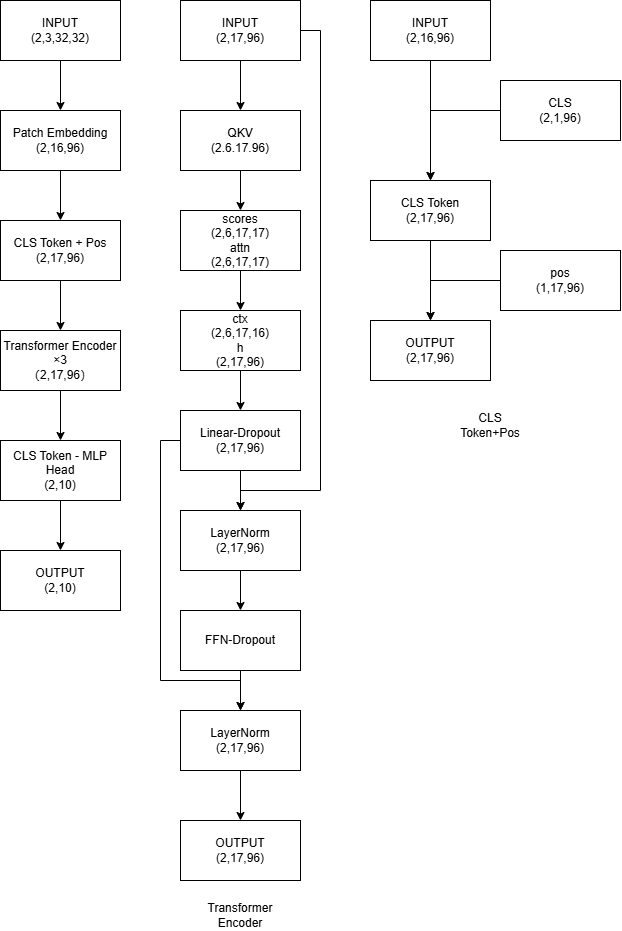

In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F
class MHA(nn.Module):
    def __init__(self,d_model=96,n_heads=6,ffn=128,dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model,self.n_heads,self.d_head = d_model,n_heads,d_model // n_heads
        self.q = nn.Linear(d_model,d_model)
        self.k = nn.Linear(d_model,d_model)
        self.v = nn.Linear(d_model,d_model)
        self.out = nn.Linear(d_model,d_model)
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model,ffn),nn.GELU(),nn.Linear(ffn,d_model))
        self.drop = nn.Dropout(dropout)
    def forward(self,x,mask=None):
        B,T,D = x.shape
        Q = self.q(x).reshape(B,T,self.n_heads,self.d_head).permute(0,2,1,3)
        K = self.k(x).reshape(B,T,self.n_heads,self.d_head).permute(0,2,1,3)
        V = self.v(x).reshape(B,T,self.n_heads,self.d_head).permute(0,2,1,3)
        scores = torch.matmul(Q,K.transpose(-2,-1)) // (self.d_head ** 0.5)
        if mask is not None:
            scores = scores.mask_fill(mask == 0,float('-inf'))
        attn = self.drop(F.softmax(scores,dim=-1))
        ctx = torch.matmul(attn,V)
        h = ctx.permute(0,2,1,3).reshape(B,T,D)
        h = self.out(h)
        x = self.ln1(x+self.drop(h))
        x = self.ln2(x+self.drop(self.ffn(x)))
        return x
class ViT(nn.Module):
    def __init__(self,img=32,d_model=96,in_ch=3,n_heads=6,patch=8,depth=3,n_classes=10):
        super().__init__()
        assert img % patch == 0
        self.img = img
        self.patch = patch
        self.grid = img // patch
        self.n_patches = self.grid * self.grid
        self.patch_dim = in_ch * patch * patch
        self.patch_proj = nn.Linear(self.patch_dim,d_model)
        self.cls = nn.Parameter(torch.zeros(1,1,d_model))
        self.pos = nn.Parameter(torch.zeros(1,self.n_patches+1,d_model))
        self.blocks = nn.ModuleList([
            MHA(d_model=d_model,n_heads=n_heads,ffn=d_model*2)
            for _ in range(depth)
        ])
        self.head = nn.Linear(d_model,n_classes)
        nn.init.trunc_normal_(self.cls,std=0.02)
        nn.init.trunc_normal_(self.pos,std=0.02)
    def forward(self,x):
        B,C,H,W = x.shape
        g = self.grid
        x = x.reshape(B,C,g,self.patch,g,self.patch)
        x = x.permute(0,2,4,1,3,5).contiguous()
        x = x.reshape(B,self.n_patches,self.patch_dim)
        x = self.patch_proj(x)
        cls = self.cls.expand(B,-1,-1)
        x = torch.cat([cls,x],dim=1)+self.pos
        for blk in self.blocks:
            x = blk(x)
        return self.head(x[:,0])
model = ViT()
model.eval()
with torch.no_grad():
    out = model(torch.randn(2,3,32,32))
    print(out.shape)
from PIL import Image
import IPython.display as display
img = Image.open('ViT.png')
display.display(img)

torch.Size([2, 1, 256])


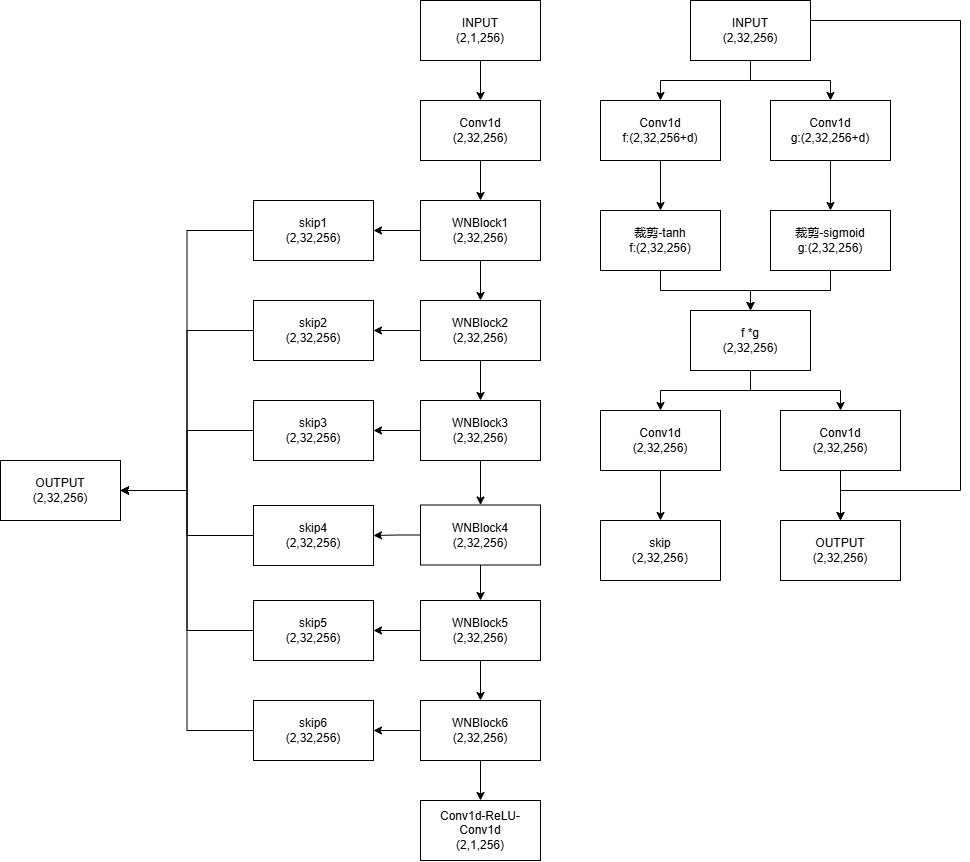

In [35]:
import torch
import torch.nn as nn
class WaveNet(nn.Module):
    class WNBlock(nn.Module):
        def __init__(self,ch,dilation):
            super().__init__()
            self.conv_f = nn.Conv1d(ch,ch,2,dilation=dilation,padding=dilation)
            self.conv_g = nn.Conv1d(ch,ch,2,dilation=dilation,padding=dilation)
            self.res = nn.Conv1d(ch,ch,1)
            self.skip = nn.Conv1d(ch,ch,1)
        def forward(self,x):
            f = torch.tanh(self.conv_f(x)[...,:x.size(-1)])
            g = torch.sigmoid(self.conv_g(x)[...,:x.size(-1)])
            h = f * g
            return self.res(h) + x,self.skip(h)
    def __init__(self,in_ch=1,ch=32,dilations=(1,2,4,8,16,32)):
        super().__init__()
        self.proj = nn.Conv1d(in_ch,ch,1)
        self.blocks = nn.ModuleList([self.WNBlock(ch,d) for d in dilations])
        self.out = nn.Sequential(
            nn.Conv1d(ch,ch,1),nn.ReLU(),
            nn.Conv1d(ch,in_ch,1),
        )
    def forward(self,x):
        x = self.proj(x)
        skips = None
        for b in self.blocks:
            x, s = b(x)
            skips = s if skips is None else skips + s
        return self.out(skips)
model = WaveNet()
model.eval()
with torch.no_grad():
    out = model(torch.randn(2,1,256))
    print(out.shape)
from PIL import Image
import IPython.display as display
img = Image.open('WaveNet.png')
display.display(img)